In [3]:
from __future__ import annotations

import math
from dataclasses import dataclass, field
from typing import Any, Dict, Iterable, Optional, Tuple

import pandas as pd


def sigmoid(x: float) -> float:
	if x >= 0:
		z = math.exp(-x)
		return 1.0 / (1.0 + z)
	z = math.exp(x)
	return z / (1.0 + z)


def gap_decay(delta_trimestres: int, lambda_half: float = 8.0) -> float:
	"""w(\Delta)=2^{-\,\Delta/\lambda_{1/2}}."""
	if delta_trimestres < 0:
		raise ValueError(f"delta_trimestres debe ser >= 0. Recibido: {delta_trimestres}")
	return math.pow(2.0, -delta_trimestres / lambda_half)


def tri_num_a_ordinal(tri_num: int) -> int:
	"""ord(YYYYP)=3*YYYY+p, con p∈{0,1,2}."""
	tri_num = int(tri_num)
	anio = tri_num // 10
	periodo = tri_num % 10
	if periodo not in (0, 1, 2):
		raise ValueError(f"tri_num inválido para codificación real: {tri_num}")
	return anio * 3 + periodo


def _tri_series_to_timestamp(s: pd.Series) -> pd.Series:
	"""t(tri) para etiquetas '2013-Otoño', '13O' o fechas parseables."""
	def parse_one(x: Any) -> pd.Timestamp:
		if pd.isna(x):
			return pd.NaT

		txt = str(x).strip()

		match_nuevo = __import__("re").fullmatch(r"(\d{4})-(Invierno|Primavera|Otoño)", txt, __import__("re").IGNORECASE)
		if match_nuevo:
			anio = int(match_nuevo.group(1))
			nombre = match_nuevo.group(2).lower()
			periodo = {"invierno": 0, "primavera": 1, "otoño": 2}[nombre]
			mes = {0: 1, 1: 5, 2: 9}[periodo]
			return pd.Timestamp(year=anio, month=mes, day=1)

		match_antiguo = __import__("re").fullmatch(r"(\d{2,4})([IOP])", txt.upper())
		if match_antiguo:
			anio_txt, periodo_txt = match_antiguo.groups()
			anio = int(anio_txt)
			if len(anio_txt) == 2:
				anio += 2000
			periodo = {"I": 0, "P": 1, "O": 2}[periodo_txt]
			mes = {0: 1, 1: 5, 2: 9}[periodo]
			return pd.Timestamp(year=anio, month=mes, day=1)

		return pd.to_datetime(txt, errors="coerce")

	return s.map(parse_one)


def build_tri_ord(df: pd.DataFrame) -> pd.Series:
	"""ord_t creciente por trimestre; si tri_num es real usa distancia trimestral exacta."""
	if "tri_num" in df.columns:
		tri_num = pd.to_numeric(df["tri_num"], errors="coerce")
		if tri_num.notna().all():
			tri_num_int = tri_num.astype(int)
			es_real = ((tri_num_int >= 10000) & (tri_num_int.mod(10).isin([0, 1, 2]))).all()
			if es_real:
				return tri_num_int.map(tri_num_a_ordinal).astype(int)

			vals = sorted(tri_num_int.unique().tolist())
			rank_map = {v: i + 1 for i, v in enumerate(vals)}
			return tri_num_int.map(rank_map).astype(int)

	if "tri" in df.columns:
		tri_ts = _tri_series_to_timestamp(df["tri"])
		if tri_ts.isna().any():
			raise ValueError("No se pudo derivar tri_ord desde 'tri' para algunas filas.")
		vals = sorted(tri_ts.unique().tolist())
		rank_map = {v: i + 1 for i, v in enumerate(vals)}
		return tri_ts.map(rank_map).astype(int)

	raise ValueError("Se requiere 'tri_num' o 'tri' para construir tri_ord.")


@dataclass
class RHatTemporalModel:
	"""
	Score seen:
		S_ij = sigma(a * (B_ij - c)) * G_ij
		B_ij = (1 - w_cont) * (w_r * r_ij^(a) + w_e * e_ij^(a)) + w_cont * C_ij
		r_ij^(a) = (N_ij + alpha) / (N_ia + alpha K_a)
		e_ij^(a) = [ (N_ij / N_ia) * (log((E_a + 1)/(df_j + 1)) + 1) ] / max_a
		C_ij = promedio_k 2^{- (t_{k+1} - t_k) / lambda_half}
		G_ij = 1 - exp(-(T_ij + omega * X_ij) / kappa)

	Unseen:
		S_ij = epsilon * r_ia^(D) * q_D(j | a)

	T_ij cuenta trimestres activos del par y X_ij cuenta incidencias extra del mismo par dentro
	del mismo trimestre. C_ij mide consistencia temporal entre trimestres distintos. G_ij mide
	respaldo histórico y separa la repetición intra-trimestre de la continuidad temporal.
	"""


	# 0	alpha	4.051785
	# 1	calib_a	11.789585
	# 2	calib_c	0.735808
	# 3	extra_group_weight	0.506827
	# 4	lambda_half	9.203407
	# 5	support_k	0.751750
	# 6	w_cont	0.989783
	# 7	w_r	0.274832

	alpha: float = 4.051785
	beta: float = 1.0
	gamma: float = 1.0

	w_r: float = 0.274832
	w_e: float = 1 - w_r
	w_cont: float = 0.989783

	lambda_half: float = 9.203407

	calib_a: float = 11.789585
	calib_c: float = 0.735808

	support_k: float = 0.751750
	extra_group_weight: float = 0.506827

	unseen_epsilon: float = 5e-4
	area_prefix_len: int = 4

	is_fitted: bool = field(default=False, init=False)

	map_N_ij: Dict[Tuple[str, str], float] = field(default_factory=dict, init=False)
	map_N_i: Dict[str, float] = field(default_factory=dict, init=False)
	map_N_ia: Dict[Tuple[str, str], float] = field(default_factory=dict, init=False)
	map_N_j: Dict[str, float] = field(default_factory=dict, init=False)
	map_N_a: Dict[str, float] = field(default_factory=dict, init=False)

	map_T_ij: Dict[Tuple[str, str], int] = field(default_factory=dict, init=False)
	map_extra_same_tri_ij: Dict[Tuple[str, str], int] = field(default_factory=dict, init=False)
	map_mean_mult_ij: Dict[Tuple[str, str], float] = field(default_factory=dict, init=False)
	map_continuity_ij: Dict[Tuple[str, str], float] = field(default_factory=dict, init=False)

	map_df_j_area: Dict[str, int] = field(default_factory=dict, init=False)
	map_E_a: Dict[str, int] = field(default_factory=dict, init=False)
	map_area: Dict[str, str] = field(default_factory=dict, init=False)
	map_U_a: Dict[str, int] = field(default_factory=dict, init=False)

	map_M_ia: Dict[Tuple[str, str], float] = field(default_factory=dict, init=False)
	map_M_i: Dict[str, float] = field(default_factory=dict, init=False)
	map_M_a: Dict[str, float] = field(default_factory=dict, init=False)

	n_profesores: int = field(default=0, init=False)
	n_ueas: int = field(default=0, init=False)
	n_areas: int = field(default=0, init=False)

	_e_tilde_max_area: Dict[str, float] = field(default_factory=dict, init=False)

	def __post_init__(self) -> None:
		for name, val in {
			"alpha": self.alpha,
			"beta": self.beta,
			"gamma": self.gamma,
			"lambda_half": self.lambda_half,
			"calib_a": self.calib_a,
			"support_k": self.support_k,
		}.items():
			if val <= 0:
				raise ValueError(f"{name} debe ser > 0. Recibido: {val}")

		if abs(self.w_r + self.w_e - 1.0) > 1e-9:
			raise ValueError("w_r + w_e debe ser 1.")
		if not (0.0 <= self.w_cont <= 1.0):
			raise ValueError("w_cont debe estar en [0,1].")
		if not (0.0 <= self.extra_group_weight <= 1.0):
			raise ValueError("extra_group_weight debe estar en [0,1].")
		if not (0.0 < self.unseen_epsilon < 0.01):
			raise ValueError("unseen_epsilon debe estar en (0, 0.01).")

	def _ensure_fitted(self) -> None:
		if not self.is_fitted:
			raise RuntimeError("Modelo no ajustado. Ejecuta fit() primero.")

	def _extract_area(self, uea: Any) -> str:
		s = str(uea).strip()
		if len(s) < self.area_prefix_len:
			raise ValueError(f"UEA '{s}' demasiado corta.")
		return s[: self.area_prefix_len]

	def fit(self, df_hist: pd.DataFrame) -> "RHatTemporalModel":
		"""Ajusta N_ij, r_ij^(a), e_ij^(a), C_ij y G_ij desde incidencias históricas."""
		if not isinstance(df_hist, pd.DataFrame):
			raise TypeError("df_hist debe ser pandas.DataFrame.")
		if "eco" not in df_hist.columns or "uea" not in df_hist.columns:
			raise ValueError("df_hist debe contener 'eco' y 'uea'.")

		df = df_hist.copy()
		df["eco"] = df["eco"].astype(str).str.strip()
		df["uea"] = df["uea"].astype(str).str.strip()
		df["area"] = df["uea"].map(self._extract_area)
		df["tri_ord"] = build_tri_ord(df)

		self.n_profesores = int(df["eco"].nunique())
		self.n_ueas = int(df["uea"].nunique())
		self.n_areas = int(df["area"].nunique())

		self.map_area = (
			df[["uea", "area"]]
			.drop_duplicates()
			.set_index("uea")["area"]
			.to_dict()
		)

		T_ij = (
			df.groupby(["eco", "uea"])
			.size()
			.reset_index(name="N_ij")
		)
		T_i = (
			df.groupby("eco")
			.size()
			.reset_index(name="N_i")
		)
		T_ia = (
			df.groupby(["eco", "area"])
			.size()
			.reset_index(name="N_ia")
		)
		T_j = (
			df.groupby(["uea", "area"])
			.size()
			.reset_index(name="N_j")
		)
		T_a = (
			T_j.groupby("area")["N_j"]
			.sum()
			.reset_index(name="N_a")
		)
		U_a = (
			T_j.groupby("area")["uea"]
			.nunique()
			.reset_index(name="num_ueas_area")
		)

		self.map_N_ij = {(r.eco, r.uea): float(r.N_ij) for r in T_ij.itertuples(index=False)}
		self.map_N_i = {r.eco: float(r.N_i) for r in T_i.itertuples(index=False)}
		self.map_N_ia = {(r.eco, r.area): float(r.N_ia) for r in T_ia.itertuples(index=False)}
		self.map_N_j = {r.uea: float(r.N_j) for r in T_j.itertuples(index=False)}
		self.map_N_a = {r.area: float(r.N_a) for r in T_a.itertuples(index=False)}
		self.map_U_a = {r.area: int(r.num_ueas_area) for r in U_a.itertuples(index=False)}

		df_j_area_counts = (
			df.groupby("uea")["eco"]
			.nunique()
			.reset_index(name="df_j")
		)
		E_a_counts = (
			df.groupby("area")["eco"]
			.nunique()
			.reset_index(name="E_a")
		)
		self.map_df_j_area = {r.uea: int(r.df_j) for r in df_j_area_counts.itertuples(index=False)}
		self.map_E_a = {r.area: int(r.E_a) for r in E_a_counts.itertuples(index=False)}

		T_M_ia = (
			df.groupby(["eco", "area"])["uea"]
			.nunique()
			.reset_index(name="M_ia")
		)
		T_M_i = (
			T_M_ia.groupby("eco")["M_ia"]
			.sum()
			.reset_index(name="M_i")
		)
		T_M_a = (
			T_M_ia.groupby("area")["M_ia"]
			.sum()
			.reset_index(name="M_a")
		)
		self.map_M_ia = {(r.eco, r.area): float(r.M_ia) for r in T_M_ia.itertuples(index=False)}
		self.map_M_i = {r.eco: float(r.M_i) for r in T_M_i.itertuples(index=False)}
		self.map_M_a = {r.area: float(r.M_a) for r in T_M_a.itertuples(index=False)}

		by_pair_trim = (
			df.groupby(["eco", "uea", "tri_ord"])
			.size()
			.reset_index(name="n_ijt")
			.sort_values(["eco", "uea", "tri_ord"])
			.reset_index(drop=True)
		)

		T_active = (
			by_pair_trim.groupby(["eco", "uea"])["tri_ord"]
			.nunique()
			.reset_index(name="T_ij")
		)
		self.map_T_ij = {(r.eco, r.uea): int(r.T_ij) for r in T_active.itertuples(index=False)}

		tmp_extra = by_pair_trim.copy()
		tmp_extra["extra_same_tri"] = (tmp_extra["n_ijt"] - 1).clip(lower=0)
		extra_same_tri = (
			tmp_extra.groupby(["eco", "uea"])["extra_same_tri"]
			.sum()
			.reset_index(name="extra_same_tri_ij")
		)
		self.map_extra_same_tri_ij = {
			(r.eco, r.uea): int(r.extra_same_tri_ij) for r in extra_same_tri.itertuples(index=False)
		}

		mean_mult = (
			by_pair_trim.groupby(["eco", "uea"])["n_ijt"]
			.mean()
			.reset_index(name="mean_mult_ij")
		)
		self.map_mean_mult_ij = {
			(r.eco, r.uea): float(r.mean_mult_ij) for r in mean_mult.itertuples(index=False)
		}

		continuity_map: Dict[Tuple[str, str], float] = {}
		for (eco, uea), sub in by_pair_trim.groupby(["eco", "uea"], sort=False):
			ords = sorted(sub["tri_ord"].astype(int).tolist())
			if len(ords) <= 1:
				continuity_map[(eco, uea)] = 0.0
				continue
			gaps = [ords[k] - ords[k - 1] for k in range(1, len(ords))]
			weights = [gap_decay(g, self.lambda_half) for g in gaps]
			continuity_map[(eco, uea)] = float(sum(weights) / len(weights))
		self.map_continuity_ij = continuity_map

		e_tilde_by_area: Dict[str, float] = {}
		for (eco_, uea_), n_ij in self.map_N_ij.items():
			area_ = self.map_area.get(uea_, "")
			n_ia = self.map_N_ia.get((eco_, area_), 0.0)
			E_a = self.map_E_a.get(area_, 1)
			df_j = self.map_df_j_area.get(uea_, 1)
			if n_ia > 0:
				tf = n_ij / n_ia
				idf = math.log((E_a + 1) / (df_j + 1)) + 1.0
				val = tf * idf
				if val > e_tilde_by_area.get(area_, 0.0):
					e_tilde_by_area[area_] = val
		self._e_tilde_max_area = {a: max(v, 1e-9) for a, v in e_tilde_by_area.items()}

		self.is_fitted = True
		return self

	def _compute_r_ij_area(self, eco: str, uea: str, area: str) -> float:
		"""r_ij^(a)=(N_ij+alpha)/(N_ia+alpha K_a)."""
		n_ij = self.map_N_ij.get((eco, uea), 0.0)
		n_ia = self.map_N_ia.get((eco, area), 0.0)
		K_a = self.map_U_a.get(area, 1)
		return (n_ij + self.alpha) / (n_ia + self.alpha * K_a)

	def _compute_r_ia(self, eco: str, area: str) -> float:
		"""r_ia^(D)=(M_ia+beta)/sqrt((M_i+beta|A|)(M_a+beta|E|))."""
		M_ia = self.map_M_ia.get((eco, area), 0.0)
		M_i = self.map_M_i.get(eco, 0.0)
		M_a = self.map_M_a.get(area, 0.0)
		num = M_ia + self.beta
		den = math.sqrt(
			(M_i + self.beta * self.n_areas) *
			(M_a + self.beta * self.n_profesores)
		)
		return num / den if den > 0 else 0.0

	def _compute_q_D(self, uea: str, area: str) -> float:
		"""q_D(j|a)=(N_j+gamma)/(N_a+gamma K_a)."""
		N_j = self.map_N_j.get(uea, 0.0)
		N_a = self.map_N_a.get(area, 0.0)
		K_a = self.map_U_a.get(area, 0)
		if N_a <= 0 or K_a <= 0:
			return 0.0
		return (N_j + self.gamma) / (N_a + self.gamma * K_a)

	def _compute_e_ij_area(self, eco: str, uea: str, area: str) -> float:
		"""e_ij^(a)=((N_ij/N_ia)(log((E_a+1)/(df_j+1))+1))/max_a."""
		N_ij = self.map_N_ij.get((eco, uea), 0.0)
		N_ia = self.map_N_ia.get((eco, area), 0.0)
		E_a = self.map_E_a.get(area, 1)
		df_j = self.map_df_j_area.get(uea, 1)
		if N_ia <= 0 or N_ij <= 0:
			return 0.0
		tf = N_ij / N_ia
		idf = math.log((E_a + 1) / (df_j + 1)) + 1.0
		e_max = self._e_tilde_max_area.get(area, 1.0)
		return (tf * idf) / e_max

	def _compute_continuity_ij(self, eco: str, uea: str) -> float:
		"""C_ij=promedio_k 2^{-gap_k/lambda_half}."""
		return self.map_continuity_ij.get((eco, uea), 0.0)

	def _compute_support(self, eco: str, uea: str) -> Tuple[float, float, int, int, float]:
		"""G_ij=1-exp(-(T_ij+omega X_ij)/kappa)."""
		T_ij = self.map_T_ij.get((eco, uea), 0)
		extra_same_tri = self.map_extra_same_tri_ij.get((eco, uea), 0)
		mean_mult = self.map_mean_mult_ij.get((eco, uea), 0.0)
		support_equiv = T_ij + self.extra_group_weight * extra_same_tri
		support = 1.0 - math.exp(-support_equiv / self.support_k) if support_equiv > 0 else 0.0
		return support, support_equiv, T_ij, extra_same_tri, mean_mult

	def _compute_seen_score(self, eco: str, uea: str, area: str) -> Dict[str, float]:
		"""S_ij seen = sigma(a(B_ij-c)) G_ij."""
		r_area = self._compute_r_ij_area(eco, uea, area)
		e_area = self._compute_e_ij_area(eco, uea, area)
		continuity = self._compute_continuity_ij(eco, uea)

		b_hist = self.w_r * r_area + self.w_e * e_area
		b_mix = (1.0 - self.w_cont) * b_hist + self.w_cont * continuity
		calibrated = sigmoid(self.calib_a * (b_mix - self.calib_c))

		support, support_equiv, T_ij, extra_same_tri, mean_mult = self._compute_support(eco, uea)
		score = calibrated * support

		return {
			"r_ij_area": r_area,
			"e_ij_area": e_area,
			"continuity_ij": continuity,
			"b_hist_ij": b_hist,
			"b_mix_ij": b_mix,
			"calibrated_ij": calibrated,
			"support_ij": support,
			"support_equiv_ij": support_equiv,
			"T_ij": T_ij,
			"extra_same_tri_ij": extra_same_tri,
			"mean_mult_ij": mean_mult,
			"score_seen_ij": score,
		}

	def predict(self, eco: Any, uea: Any) -> float:
		"""Devuelve S_ij."""
		self._ensure_fitted()
		eco_str = str(eco).strip()
		uea_str = str(uea).strip()
		area_str = self._extract_area(uea_str)

		N_j = self.map_N_j.get(uea_str, 0.0)
		N_i = self.map_N_i.get(eco_str, 0.0)
		N_ij = self.map_N_ij.get((eco_str, uea_str), 0.0)

		if N_j == 0.0:
			return 0.0

		if N_i == 0.0 or N_ij == 0.0:
			r_ia = self._compute_r_ia(eco_str, area_str)
			q_D = self._compute_q_D(uea_str, area_str)
			return float(self.unseen_epsilon * r_ia * q_D)

		seen = self._compute_seen_score(eco_str, uea_str, area_str)
		return float(seen["score_seen_ij"])

	def explain(self, eco: Any, uea: Any) -> Dict[str, Any]:
		"""Devuelve términos de la descomposición de S_ij."""
		self._ensure_fitted()
		eco_str = str(eco).strip()
		uea_str = str(uea).strip()
		area_str = self._extract_area(uea_str)

		N_ij = self.map_N_ij.get((eco_str, uea_str), 0.0)
		N_i = self.map_N_i.get(eco_str, 0.0)
		N_ia = self.map_N_ia.get((eco_str, area_str), 0.0)
		N_j = self.map_N_j.get(uea_str, 0.0)
		N_a = self.map_N_a.get(area_str, 0.0)

		r_ia = self._compute_r_ia(eco_str, area_str)
		q_D = self._compute_q_D(uea_str, area_str)
		unseen_score = self.unseen_epsilon * r_ia * q_D

		base = {
			"eco": eco_str,
			"uea": uea_str,
			"area": area_str,
			"N_ij": N_ij,
			"N_i": N_i,
			"N_ia": N_ia,
			"N_j": N_j,
			"N_a": N_a,
			"df_j_area": self.map_df_j_area.get(uea_str, 0),
			"E_a": self.map_E_a.get(area_str, 0),
			"M_ia": self.map_M_ia.get((eco_str, area_str), 0.0),
			"r_ia_D": r_ia,
			"q_D_j_given_a": q_D,
			"unseen_branch_score": unseen_score,
			"cold_start_profesor": bool(N_i == 0.0),
			"uea_nunca_vista_global": bool(N_j == 0.0),
			"par_nunca_visto": bool(N_ij == 0.0),
		}

		if N_j == 0.0:
			base["R_hat_ij"] = 0.0
			return base

		if N_i == 0.0 or N_ij == 0.0:
			base["R_hat_ij"] = float(unseen_score)
			return base

		seen = self._compute_seen_score(eco_str, uea_str, area_str)
		base.update(seen)
		base["R_hat_ij"] = float(seen["score_seen_ij"])
		return base

	def score_candidates_for_uea(
		self,
		uea: Any,
		profesores: Iterable[Any],
		sort_desc: bool = True,
	) -> pd.DataFrame:
		"""Construye ranking de profesores para una UEA."""
		self._ensure_fitted()
		uea_str = str(uea).strip()
		rows = [self.explain(eco=str(p).strip(), uea=uea_str) for p in profesores]
		out = pd.DataFrame(rows)
		if sort_desc:
			out = out.sort_values("R_hat_ij", ascending=False).reset_index(drop=True)
		return out

	def predict_dataframe(
		self,
		df_pred: pd.DataFrame,
		eco_col: str = "eco",
		uea_col: str = "uea",
		return_explain_cols: bool = False,
	) -> pd.DataFrame:
		"""Evalúa S_ij para filas de predicción."""
		self._ensure_fitted()
		for col in (eco_col, uea_col):
			if col not in df_pred.columns:
				raise ValueError(f"Falta columna '{col}' en df_pred.")

		df = df_pred.copy()
		df[eco_col] = df[eco_col].astype(str).str.strip()
		df[uea_col] = df[uea_col].astype(str).str.strip()

		if return_explain_cols:
			rows = [self.explain(r[eco_col], r[uea_col]) for _, r in df.iterrows()]
			return df.join(pd.DataFrame(rows).drop(columns=["eco", "uea", "area"], errors="ignore"))

		df["R_hat_ij"] = [self.predict(r[eco_col], r[uea_col]) for _, r in df.iterrows()]
		return df




<>:19: SyntaxWarning: invalid escape sequence '\D'
<>:19: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_1060/2548732614.py:19: SyntaxWarning: invalid escape sequence '\D'
  """w(\Delta)=2^{-\,\Delta/\lambda_{1/2}}."""


In [4]:
df_hist = pd.read_json("/content/df_hist.json")
modelo = RHatTemporalModel()
modelo.fit(df_hist)
#info = modelo.explain("14416", "1113085")
#info = modelo.explain("28650", "1112022")
info = modelo.explain("28650", "1112034")
print(info["R_hat_ij"])
#print(info)

0.8222333159798022


In [ ]:
print(modelo.lambda_half)
print(modelo.w_cont)
print(modelo.calib_a)
print(modelo.calib_c)
print(modelo.support_k)
print(modelo.extra_group_weight)
print(modelo.w_r, modelo.w_e)
print(modelo.explain("14416", "1113085"))

Mejores hiperparámetros


,parametro,valor
0,alpha,5.031014
1,calib_a,13.561742
2,calib_c,0.758588
3,extra_group_weight,0.555002
4,lambda_half,3.058488
5,support_k,0.536177
6,w_cont,0.982414
7,w_r,0.555878


Pérdida cuadrática total: 0.0241401740
Pérdida absoluta total: 0.2497797072
Resultados por objetivo


,eco,uea,target,pred,error,abs_error,weighted_sq_error
0,28650,1112034,0.8,0.798689,-0.001311,0.001311,0.000002
1,28650,1112036,0.6,0.477245,-0.122755,0.122755,0.009041
2,28650,1112022,0.6,0.713496,0.113496,0.113496,0.010305
3,14416,1113085,0.9,0.838635,-0.061365,0.061365,0.003766
4,14416,1111078,0.2,0.245306,0.045306,0.045306,0.001026


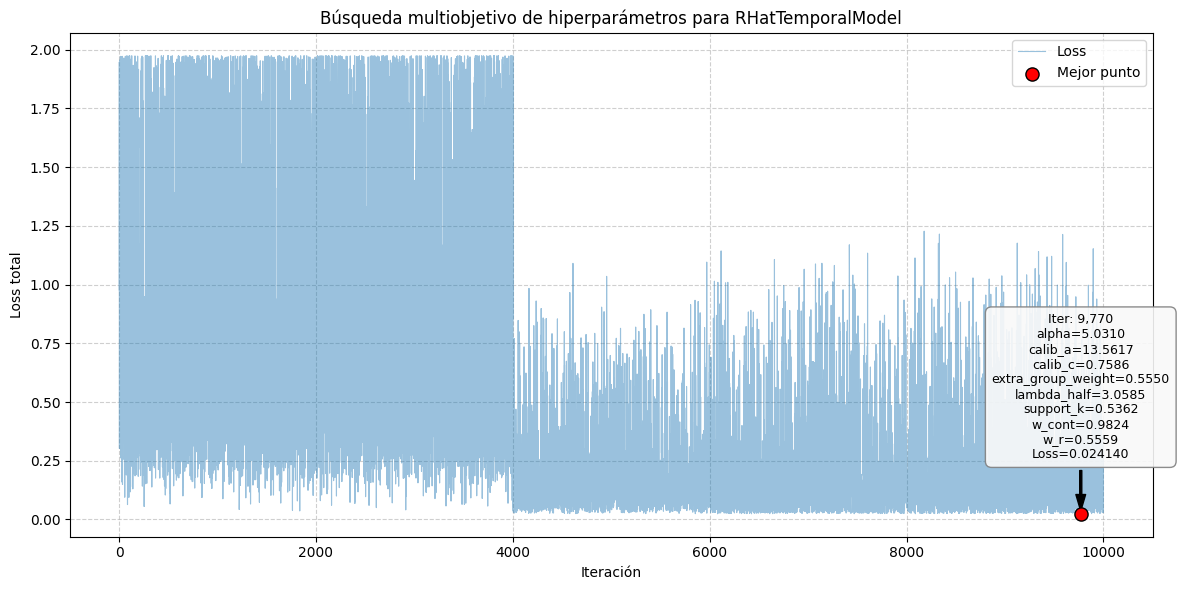

In [10]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

if "modelo_rhat" not in globals() or not isinstance(modelo_rhat, RHatTemporalModel) or not modelo_rhat.is_fitted:
	modelo_rhat = RHatTemporalModel()
	modelo_rhat.fit(df_hist)

eco_prueba = "28650"
eco_prueba2 = "14416"

objetivos_rhat = [
	{"eco": eco_prueba, "uea": "1112034", "target": 0.8, "peso": 1.0},
 	{"eco": eco_prueba, "uea": "1112036", "target": 0.6, "peso": 0.6},
	{"eco": eco_prueba, "uea": "1112022", "target": 0.6, "peso": 0.8},
  {"eco": eco_prueba2, "uea": "1113085", "target": 0.9, "peso": 1.0},
  {"eco": eco_prueba2, "uea": "1111078", "target": 0.2, "peso": 0.5},
]

def es_seen(info):
	return (float(info["N_i"]) > 0.0) and (float(info["N_j"]) > 0.0) and (float(info["N_ij"]) > 0.0)

infos_objetivos_rhat = []
for obj in objetivos_rhat:
	info = modelo_rhat.explain(obj["eco"], obj["uea"])
	infos_objetivos_rhat.append(info)

hay_seen_rhat = any(es_seen(info) for info in infos_objetivos_rhat)
hay_unseen_rhat = any(not es_seen(info) for info in infos_objetivos_rhat)

param_ranges_rhat = {}
if hay_seen_rhat:
	param_ranges_rhat.update(
		{
			"alpha": (0.001, 8.0),
			"w_r": (0.0, 1.0),
			"w_cont": (0.0, 1.0),
			"lambda_half": (1.0, 24.0),
			"calib_a": (0.5, 20.0),
			"calib_c": (0.0, 1.0),
			"support_k": (0.25, 12.0),
			"extra_group_weight": (0.0, 1.0),
		}
	)

if hay_unseen_rhat:
	param_ranges_rhat.update(
		{
			"beta": (0.001, 8.0),
			"gamma": (0.001, 8.0),
			"unseen_epsilon": (1e-6, 1e-2),
		}
	)

parametros_actuales_rhat = {
		"alpha": float(modelo_rhat.alpha),
		"beta": float(modelo_rhat.beta),
		"gamma": float(modelo_rhat.gamma),
		"unseen_epsilon": float(modelo_rhat.unseen_epsilon),
		"w_r": float(modelo_rhat.w_r),
		"w_e": float(modelo_rhat.w_e),
		"w_cont": float(modelo_rhat.w_cont),
		"lambda_half": float(modelo_rhat.lambda_half),
		"calib_a": float(modelo_rhat.calib_a),
		"calib_c": float(modelo_rhat.calib_c),
		"support_k": float(modelo_rhat.support_k),
		"extra_group_weight": float(modelo_rhat.extra_group_weight),
}

def aplicar_params_rhat(modelo, params):
	for k, v in params.items():
		setattr(modelo, k, float(v))
	if "w_r" in params:
		modelo.w_e = float(1.0 - modelo.w_r)

def sample_params_rhat(rng, ranges):
	return {k: float(rng.uniform(lo, hi)) for k, (lo, hi) in ranges.items()}

def shrink_ranges_rhat(best_params, ranges, factor):
	new_ranges = {}
	for k, (lo, hi) in ranges.items():
		span = (hi - lo) * factor
		center = float(best_params[k])
		new_lo = max(lo, center - span / 2.0)
		new_hi = min(hi, center + span / 2.0)
		if math.isclose(new_lo, new_hi):
			new_lo = new_hi = center
		new_ranges[k] = (new_lo, new_hi)
	return new_ranges

def evaluar_params_multi_rhat(modelo, params, objetivos):
	aplicar_params_rhat(modelo, params)
	rows = []
	total_sq = 0.0
	total_abs = 0.0
	for obj in objetivos:
		pred = float(modelo.predict(obj["eco"], obj["uea"]))
		err = pred - float(obj["target"])
		abs_err = abs(err)
		sq_err = err * err
		weighted_sq = float(obj["peso"]) * sq_err
		weighted_abs = float(obj["peso"]) * abs_err
		total_sq += weighted_sq
		total_abs += weighted_abs
		rows.append(
			{
				"eco": obj["eco"],
				"uea": obj["uea"],
				"target": float(obj["target"]),
				"pred": pred,
				"error": err,
				"abs_error": abs_err,
				"weighted_sq_error": weighted_sq,
			}
		)
	return total_sq, total_abs, pd.DataFrame(rows)

rng_rhat = np.random.default_rng(42)

n_random_inicial_rhat = 4000
n_random_refine_rhat = 2000
n_refinamientos_rhat = 3
shrink_factor_rhat = 0.25

hist_loss_rhat = []
best_loss_rhat = float("inf")
best_abs_rhat = float("inf")
best_params_rhat = None
best_df_eval_rhat = None
best_iter_rhat = 0

current_ranges_rhat = dict(param_ranges_rhat)
iter_global_rhat = 0

for _ in range(n_random_inicial_rhat):
	iter_global_rhat += 1
	params = sample_params_rhat(rng_rhat, current_ranges_rhat)
	loss, abs_loss, df_eval = evaluar_params_multi_rhat(modelo_rhat, params, objetivos_rhat)
	hist_loss_rhat.append(loss)
	if (loss < best_loss_rhat) or (math.isclose(loss, best_loss_rhat) and abs_loss < best_abs_rhat):
		best_loss_rhat = loss
		best_abs_rhat = abs_loss
		best_params_rhat = dict(params)
		best_df_eval_rhat = df_eval.copy()
		best_iter_rhat = iter_global_rhat

for _ in range(n_refinamientos_rhat):
	current_ranges_rhat = shrink_ranges_rhat(best_params_rhat, param_ranges_rhat, shrink_factor_rhat)
	for _ in range(n_random_refine_rhat):
		iter_global_rhat += 1
		params = sample_params_rhat(rng_rhat, current_ranges_rhat)
		loss, abs_loss, df_eval = evaluar_params_multi_rhat(modelo_rhat, params, objetivos_rhat)
		hist_loss_rhat.append(loss)
		if (loss < best_loss_rhat) or (math.isclose(loss, best_loss_rhat) and abs_loss < best_abs_rhat):
			best_loss_rhat = loss
			best_abs_rhat = abs_loss
			best_params_rhat = dict(params)
			best_df_eval_rhat = df_eval.copy()
			best_iter_rhat = iter_global_rhat

aplicar_params_rhat(modelo_rhat, best_params_rhat)

print("Mejores hiperparámetros")
display(
	pd.DataFrame(
		[{"parametro": k, "valor": float(v)} for k, v in best_params_rhat.items()]
	).sort_values("parametro").reset_index(drop=True)
)

print(f"Pérdida cuadrática total: {best_loss_rhat:.10f}")
print(f"Pérdida absoluta total: {best_abs_rhat:.10f}")

print("Resultados por objetivo")
display(best_df_eval_rhat)

plt.figure(figsize=(12, 6))
plt.plot(range(1, len(hist_loss_rhat) + 1), hist_loss_rhat, alpha=0.45, linewidth=0.8, label="Loss")
plt.scatter(
	best_iter_rhat,
	best_loss_rhat,
	color="red",
	s=90,
	edgecolors="black",
	zorder=5,
	label="Mejor punto",
)

texto_tag_rhat = "\n".join(
	[
		f"Iter: {best_iter_rhat:,}",
		*[f"{k}={float(v):.4f}" for k, v in sorted(best_params_rhat.items())],
		f"Loss={best_loss_rhat:.6f}",
	]
)

plt.annotate(
	texto_tag_rhat,
	xy=(best_iter_rhat, best_loss_rhat),
	xytext=(best_iter_rhat, best_loss_rhat + max(hist_loss_rhat) * 0.12 if hist_loss_rhat else best_loss_rhat),
	arrowprops=dict(facecolor="black", shrink=0.05, width=1.5, headwidth=7),
	fontsize=9,
	ha="center",
	bbox=dict(boxstyle="round,pad=0.5", fc="#f9f9f9", ec="gray", alpha=0.9),
)

plt.title("Búsqueda multiobjetivo de hiperparámetros para RHatTemporalModel")
plt.xlabel("Iteración")
plt.ylabel("Loss total")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

Profesores a evaluar: 1533
UEAs objetivo: 95
Predicciones a generar: 145635


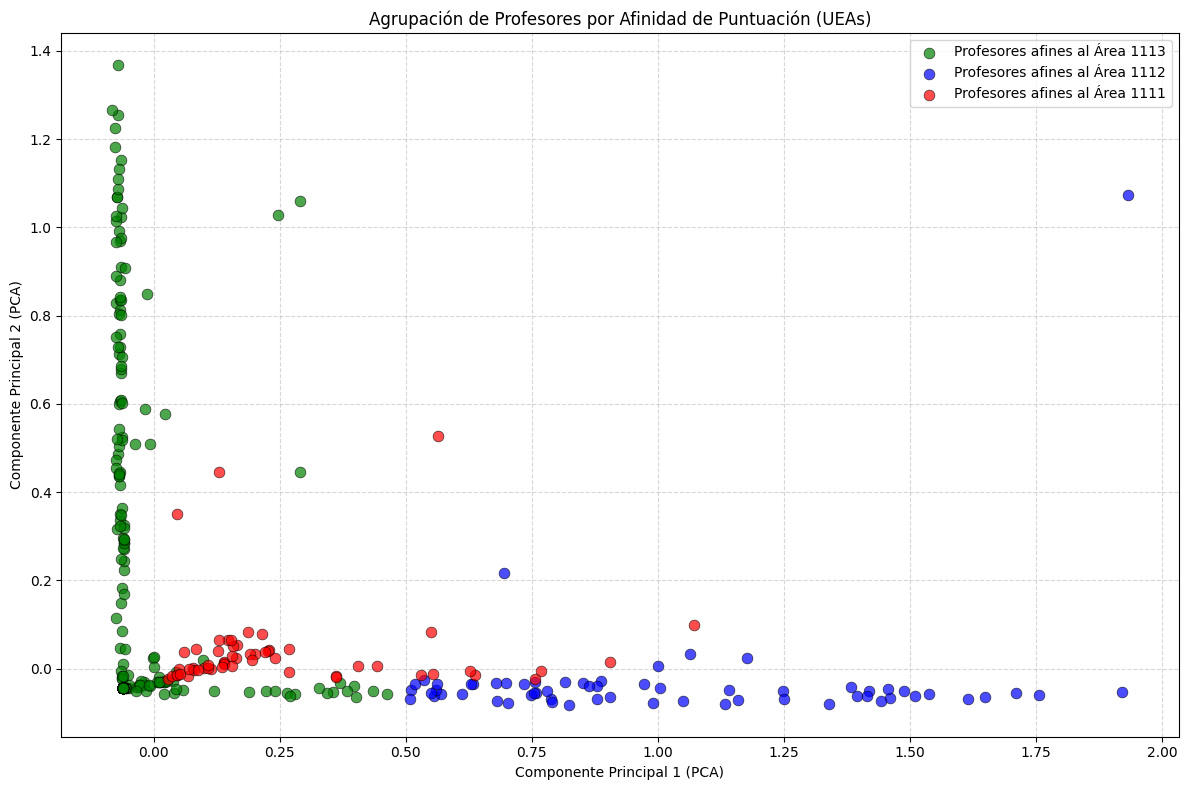

In [11]:
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

if "modelo_rhat" not in globals() or not isinstance(modelo_rhat, RHatTemporalModel) or not modelo_rhat.is_fitted:
	modelo_rhat = RHatTemporalModel()
	modelo_rhat.fit(df_hist)

areas_colores_rhat = {
	"1110": "yellow",
	"1111": "red",
	"1112": "blue",
	"1113": "green",
}

todos_profesores_rhat = list(modelo_rhat.map_N_i.keys())
todas_ueas_rhat = list(modelo_rhat.map_N_j.keys())
ueas_filtradas_rhat = [u for u in todas_ueas_rhat if str(u)[:4] in areas_colores_rhat]

print(f"Profesores a evaluar: {len(todos_profesores_rhat)}")
print(f"UEAs objetivo: {len(ueas_filtradas_rhat)}")
print(f"Predicciones a generar: {len(todos_profesores_rhat) * len(ueas_filtradas_rhat)}")

df_pred_rhat = pd.DataFrame(
	list(itertools.product(todos_profesores_rhat, ueas_filtradas_rhat)),
	columns=["eco", "uea"]
)
df_scores_rhat = modelo_rhat.predict_dataframe(df_pred_rhat)
matriz_features_rhat = df_scores_rhat.pivot(index="eco", columns="uea", values="R_hat_ij").fillna(0.0)

n_clusters_rhat = min(4, len(matriz_features_rhat))
if n_clusters_rhat < 2:
	raise ValueError("Se requieren al menos dos profesores para graficar clústeres.")

kmeans_rhat = KMeans(n_clusters=n_clusters_rhat, random_state=42, n_init=10)
clusters_rhat = kmeans_rhat.fit_predict(matriz_features_rhat)

cluster_to_area_rhat = {}
for cluster_id in range(n_clusters_rhat):
	profs_cluster = matriz_features_rhat[clusters_rhat == cluster_id]
	suma_por_area = {area: 0.0 for area in areas_colores_rhat}
	for uea in matriz_features_rhat.columns:
		area = str(uea)[:4]
		if area in suma_por_area:
			suma_por_area[area] += float(profs_cluster[uea].sum())
	cluster_to_area_rhat[cluster_id] = max(suma_por_area, key=suma_por_area.get)

pca_rhat = PCA(n_components=2)
coords_2d_rhat = pca_rhat.fit_transform(matriz_features_rhat)

plt.figure(figsize=(12, 8))
for cluster_id in range(n_clusters_rhat):
	idx = clusters_rhat == cluster_id
	area = cluster_to_area_rhat[cluster_id]
	color = areas_colores_rhat[area]
	plt.scatter(
		coords_2d_rhat[idx, 0],
		coords_2d_rhat[idx, 1],
		c=color,
		label=f"Profesores afines al Área {area}",
		alpha=0.7,
		edgecolors="black",
		linewidths=0.5,
		s=60,
		zorder=3,
	)

plt.title("Agrupación de Profesores por Afinidad de Puntuación (UEAs)")
plt.xlabel("Componente Principal 1 (PCA)")
plt.ylabel("Componente Principal 2 (PCA)")

handles_rhat, labels_rhat = plt.gca().get_legend_handles_labels()
leyenda_unica_rhat = dict(zip(labels_rhat, handles_rhat))
plt.legend(leyenda_unica_rhat.values(), leyenda_unica_rhat.keys(), loc="best")
plt.grid(True, linestyle="--", alpha=0.5, zorder=0)
plt.tight_layout()
plt.show()

In [14]:
import json
import pandas as pd
import plotly.express as px

if "matriz_features_rhat" not in globals() or "coords_2d_rhat" not in globals():
	raise RuntimeError("Ejecuta primero la celda de clustering y gráfica PCA.")

with open("eco-nombre.json", "r", encoding="utf-8") as f:
	mapa_profesores_rhat = json.load(f)

with open("clave-uea.json", "r", encoding="utf-8") as f:
	mapa_ueas_rhat = json.load(f)

df_plot_rhat = pd.DataFrame(
	{
		"eco": matriz_features_rhat.index.astype(str),
		"PC1": coords_2d_rhat[:, 0],
		"PC2": coords_2d_rhat[:, 1],
		"Cluster_ID": clusters_rhat,
	}
)

df_plot_rhat["Nombre_Profesor"] = df_plot_rhat["eco"].map(
	lambda x: mapa_profesores_rhat.get(x, f"ECO {x}")
)
df_plot_rhat["Etiqueta_Profesor"] = df_plot_rhat.apply(
	lambda row: f'{row["Nombre_Profesor"]} (ECO {row["eco"]})',
	axis=1
)
df_plot_rhat["Area_Afin"] = df_plot_rhat["Cluster_ID"].map(cluster_to_area_rhat)

top_ueas_str_rhat = []
for eco in matriz_features_rhat.index:
	top_scores = matriz_features_rhat.loc[eco].sort_values(ascending=False).head(5)
	lineas = []
	for uea, score in top_scores.items():
		if score > 0.01:
			uea_str = str(uea)
			nombre_uea = mapa_ueas_rhat.get(uea_str, f"Clave {uea_str}")
			lineas.append(f"• {uea_str} — {nombre_uea}: {score:.3f}")
	texto = "<br>".join(lineas)
	top_ueas_str_rhat.append(texto if texto else "Sin scores altos relevantes")

df_plot_rhat["Top_Scores"] = top_ueas_str_rhat

fig_rhat = px.scatter(
	df_plot_rhat,
	x="PC1",
	y="PC2",
	color="Area_Afin",
	hover_name="Etiqueta_Profesor",
	custom_data=["Top_Scores", "eco", "Nombre_Profesor"],
	color_discrete_map=areas_colores_rhat,
	title="Agrupación de Profesores por Afinidad (Explorador Interactivo)",
	labels={
		"PC1": "Variabilidad Principal (Tendencia dominante de puntuación)",
		"PC2": "Variabilidad Secundaria (Especialización cruzada / Outliers)",
	},
)

fig_rhat.update_traces(
	marker=dict(size=12, line=dict(width=1, color="DarkSlateGrey")),
	hovertemplate=(
		"<b>%{customdata[2]}</b><br>"
		"ECO: %{customdata[1]}<br>"
		"PC1: %{x:.3f} | PC2: %{y:.3f}<br><br>"
		"<b>Top 5 UEAs de afinidad:</b><br>"
		"%{customdata[0]}"
		"<extra></extra>"
	),
)

fig_rhat.update_layout(
	plot_bgcolor="white",
	xaxis=dict(showgrid=True, gridcolor="lightgray", gridwidth=0.5, zeroline=True, zerolinecolor="gray"),
	yaxis=dict(showgrid=True, gridcolor="lightgray", gridwidth=0.5, zeroline=True, zerolinecolor="gray"),
	legend_title_text="Área Dominante",
)

fig_rhat.show()

In [5]:
import joblib
import pandas as pd

df_hist = pd.read_json("df_hist.json")

# 0	alpha	4.051785
# 1	calib_a	11.789585
# 2	calib_c	0.735808
# 3	extra_group_weight	0.506827
# 4	lambda_half	9.203407
# 5	support_k	0.751750
# 6	w_cont	0.989783
# 7	w_r	0.274832

modelo = RHatTemporalModel(
	alpha=4.051785,
	beta=1.0,
	gamma=1.0,
	w_r=0.274832,
	w_e=1.0 - 0.274832,
	w_cont=0.989783,
	lambda_half=9.203407,
	calib_a=11.789585,
	calib_c=0.735808,
	support_k=0.751750,
	extra_group_weight=0.506827,
	unseen_epsilon=5e-4,
	area_prefix_len=4,
)

modelo.fit(df_hist)

joblib.dump(modelo, "rhat_temporal_model.joblib", compress=3)
print("Modelo exportado a rhat_temporal_model.joblib")

Modelo exportado a rhat_temporal_model.joblib


In [6]:
import sys

eco = "14416"
uea = "1113085"

modelo = joblib.load("rhat_temporal_model.joblib")
score = modelo.predict(eco, uea)

print(score)

0.852917703721489


In [7]:
import itertools
import json
import os
import joblib
import pandas as pd

if "modelo_rhat" in globals() and isinstance(modelo_rhat, RHatTemporalModel) and modelo_rhat.is_fitted:
	modelo_area = modelo_rhat
elif "modelo" in globals() and isinstance(modelo, RHatTemporalModel) and modelo.is_fitted:
	modelo_area = modelo
elif os.path.exists("rhat_temporal_model.joblib"):
	modelo_area = joblib.load("rhat_temporal_model.joblib")
else:
	if "df_hist" not in globals():
		df_hist = pd.read_json("df_hist.json")
	modelo_area = RHatTemporalModel()
	modelo_area.fit(df_hist)

umbral_area = 0.1
areas_objetivo = ("1110", "1111", "1112", "1113")

todos_ecos = sorted(str(eco) for eco in modelo_area.map_N_i.keys())
todas_ueas = sorted(
	str(uea)
	for uea in modelo_area.map_N_j.keys()
	if str(uea)[:4] in areas_objetivo
)

df_pred_area = pd.DataFrame(
	itertools.product(todos_ecos, todas_ueas),
	columns=["eco", "uea"]
)

df_scores_area = modelo_area.predict_dataframe(df_pred_area)
df_scores_area["area"] = df_scores_area["uea"].str[:4]

df_max_por_area = (
	df_scores_area
	.groupby(["eco", "area"], as_index=False)["R_hat_ij"]
	.max()
	.sort_values(["eco", "area"])
)

areas_detectadas = (
	df_max_por_area[df_max_por_area["R_hat_ij"] > umbral_area]
	.groupby("eco")["area"]
	.apply(list)
	.to_dict()
)

area_profesor = {
	eco: areas_detectadas.get(eco, [])
	for eco in todos_ecos
}

with open("area_profesor.json", "w", encoding="utf-8") as file:
	json.dump(area_profesor, file, ensure_ascii=False, indent=4)



Exportado: area_profesor.json
Ejemplo 28650: ['1112']


In [9]:
print(area_profesor.get("310", []))

['1113']
